# Step4 - Best encoders × multilingual training conditions

Does multilingual training data improve classification, and does it
change the encoder ranking established in M3?

## Step4.1 - Imports

In [2]:
import os
import re

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sentence_transformers import SentenceTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report

# Raw multilingual corpus lives in static_data/raw examples/examples_<lang>.md
# (the old `example_data_loader` module was removed; leaf_loader.py is a
#  different JSON-taxonomy loader and does NOT parse these .md files).
RAW_EXAMPLES_DIR = os.path.join("static_data", "raw examples")

_HEADER_RE = re.compile(r"^###\s+\d+\s*·\s*(.+?)\s*$", re.M)


def parse_markdown_file(filename):
    """Parse an examples_<lang>.md file into a DataFrame with `label` and `text`.

    Each example is a block headed by `### NNN · <label>` followed by the text,
    separated by `---` horizontal rules.
    """
    path = os.path.join(RAW_EXAMPLES_DIR, filename)
    with open(path, encoding="utf-8") as f:
        content = f.read()

    rows = []
    for block in re.split(r"^---\s*$", content, flags=re.M):
        m = _HEADER_RE.search(block)
        if not m:
            continue
        text = block[m.end():].strip()
        if text:
            rows.append({"label": m.group(1).strip(), "text": text})
    return pd.DataFrame(rows)


# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Seaborn style for confusion matrix consistency with M1
sns.set_theme(style="whitegrid", context="notebook")

## Step4.2 - Data loader and preparation

In [3]:
# Load all 4 languages
# Train: variable per condition | Test: 10 examples per class per language (always)

N_TRAIN_PER_CLASS = 8
N_TEST_PER_CLASS = 10

LANGUAGES = ["en", "fr", "de", "it"]


def load_and_split(language):
    """Load examples_<lang>.md and apply deterministic stratified split."""
    df_raw = parse_markdown_file(f"examples_{language}.md")
    df_raw["language"] = language
    df_shuffled = df_raw.sample(frac=1, random_state=42).reset_index(drop=True)
    df_sorted = df_shuffled.sort_values("label", kind="mergesort").reset_index(drop=True)
    
    df_train_lang = df_sorted.groupby("label", group_keys=False).head(N_TRAIN_PER_CLASS).reset_index(drop=True)
    
    df_test_lang = (
        df_sorted.groupby("label", group_keys=False)[df_sorted.columns.tolist()]
        .apply(lambda g: g.iloc[N_TRAIN_PER_CLASS:N_TRAIN_PER_CLASS + N_TEST_PER_CLASS])
        .reset_index(drop=True)
    )
    
    return df_train_lang, df_test_lang


# Load all languages
train_per_lang = {}
test_per_lang = {}

for lang in LANGUAGES:
    train_per_lang[lang], test_per_lang[lang] = load_and_split(lang)
    print(f"{lang.upper()}: train={len(train_per_lang[lang])}, test={len(test_per_lang[lang])}")

# Concatenate test sets — same evaluation pool for all experiments
df_test_full = pd.concat(test_per_lang.values(), ignore_index=True)
print()
print(f"Total test pool: {len(df_test_full)} examples ({len(LANGUAGES)} languages × {N_TEST_PER_CLASS} × 5 classes)")

EN: train=40, test=50
FR: train=40, test=50
DE: train=40, test=50
IT: train=40, test=50

Total test pool: 200 examples (4 languages × 10 × 5 classes)


## Step4.3 - LAbel encoding

In [4]:
# Label encoding — fit on the union of all training data
# We use the union to ensure all classes are seen regardless of condition

# Concatenate all training data from all 4 languages to fit the encoder
all_train = pd.concat(list(train_per_lang.values()), ignore_index=True)

label_encoder = LabelEncoder()
label_encoder.fit(all_train["label"])

# Pre-encode test labels (same for all experiments)
y_test_full = label_encoder.transform(df_test_full["label"])

print(f"Classes: {list(label_encoder.classes_)}")


Classes: ['Fake-Support', 'Fake-sextortion', 'Investment-fraud', 'Phishing', 'Ransomware']


## Step4.4 - Build experiment

In [5]:
# Build the three training conditions
# A: EN-only (8/class)               → 40 examples
# B: 2/class/lang × 4 languages       → 40 examples (budget-matched to A)
# C: 8/class/lang × 4 languages       → 160 examples (full multilingual)


def build_condition_A():
    """8 EN examples per class (40 total) — baseline."""
    return train_per_lang["en"].copy()


def build_condition_B(n_per_class_per_lang=2):
    """n examples per class per language × 4 languages (40 total when n=2)."""
    parts = []
    for lang in LANGUAGES:
        # Take first n per class from each language's training set
        sub = (
            train_per_lang[lang]
            .groupby("label", group_keys=False)
            .head(n_per_class_per_lang)
            .reset_index(drop=True)
        )
        parts.append(sub)
    return pd.concat(parts, ignore_index=True)


def build_condition_C(n_per_class_per_lang=8):
    """All 8 examples per class for all 4 languages (160 total)."""
    return pd.concat(list(train_per_lang.values()), ignore_index=True)


condition_A = build_condition_A()
condition_B = build_condition_B(n_per_class_per_lang=2)
condition_C = build_condition_C(n_per_class_per_lang=8)

for cond_name, cond_df in [("A (EN only)", condition_A), 
                            ("B (2/class × 4 langs)", condition_B),
                            ("C (8/class × 4 langs)", condition_C)]:
    print(f"Condition {cond_name}: {len(cond_df)} examples total")
    print(cond_df.groupby(["language", "label"]).size().unstack(fill_value=0))
    print()

Condition A (EN only): 40 examples total
label     Fake-Support  Fake-sextortion  Investment-fraud  Phishing  \
language                                                              
en                   8                8                 8         8   

label     Ransomware  
language              
en                 8  

Condition B (2/class × 4 langs): 40 examples total
label     Fake-Support  Fake-sextortion  Investment-fraud  Phishing  \
language                                                              
de                   2                2                 2         2   
en                   2                2                 2         2   
fr                   2                2                 2         2   
it                   2                2                 2         2   

label     Ransomware  
language              
de                 2  
en                 2  
fr                 2  
it                 2  

Condition C (8/class × 4 langs): 160 examples total
label 

In [5]:
def run_experiment(encoder_name, encoder_hf_id, condition_name, train_df):
    """
    Run one experiment: 
      1. Load encoder
      2. Encode training and test sets
      3. Train LogReg head
      4. Evaluate on full 4-language test pool
      5. Compute F1 per language and overall
    """
    encoder = SentenceTransformer(encoder_hf_id)
    
    # Encode
    X_train = encoder.encode(train_df["text"].tolist(), show_progress_bar=False, convert_to_numpy=True)
    X_test = encoder.encode(df_test_full["text"].tolist(), show_progress_bar=False, convert_to_numpy=True)
    
    y_train = label_encoder.transform(train_df["label"])
    
    # Train LogReg head
    clf = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
    clf.fit(X_train, y_train)
    
    # Predict on full test pool
    y_pred = clf.predict(X_test)
    
    # Compute overall and per-language F1
    overall_f1 = f1_score(y_test_full, y_pred, average="macro", zero_division=0)
    
    per_lang_f1 = {}
    for lang in LANGUAGES:
        mask = df_test_full["language"].values == lang
        per_lang_f1[f"f1_{lang}"] = f1_score(
            y_test_full[mask], y_pred[mask],
            average="macro", zero_division=0,
        )
    
    return {
        "encoder": encoder_name,
        "condition": condition_name,
        "n_train": len(train_df),
        "overall_f1": overall_f1,
        **per_lang_f1,
        "min_f1": min(per_lang_f1.values()),
    }

In [6]:
ENCODERS = {
    "LaBSE":                          "sentence-transformers/LaBSE",
    "paraphrase-multilingual-mpnet":  "sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
    "paraphrase-xlm-r-multilingual":  "sentence-transformers/paraphrase-xlm-r-multilingual-v1",
}

CONDITIONS = {
    "A (EN only)":          condition_A,
    "B (2/class × 4 lang)": condition_B,
    "C (8/class × 4 lang)": condition_C,
}

## Step4.5 - Run experiment

In [7]:
results = []

for enc_name, enc_id in ENCODERS.items():
    for cond_name, cond_df in CONDITIONS.items():
        print(f"Running: {enc_name} | {cond_name}")
        result = run_experiment(enc_name, enc_id, cond_name, cond_df)
        results.append(result)
        print(f"  Overall F1: {result['overall_f1']:.3f} | Min F1: {result['min_f1']:.3f}")

results_df = pd.DataFrame(results)
print()
print(results_df.to_string(index=False))

Running: LaBSE | A (EN only)


/opt/anaconda3/envs/cas-aml/lib/python3.11/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  Overall F1: 0.820 | Min F1: 0.805
Running: LaBSE | B (2/class × 4 lang)


/opt/anaconda3/envs/cas-aml/lib/python3.11/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  Overall F1: 0.852 | Min F1: 0.777
Running: LaBSE | C (8/class × 4 lang)


...

  Overall F1: 0.853 | Min F1: 0.818
Running: paraphrase-xlm-r-multilingual | B (2/class × 4 lang)


/opt/anaconda3/envs/cas-aml/lib/python3.11/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  Overall F1: 0.869 | Min F1: 0.858
Running: paraphrase-xlm-r-multilingual | C (8/class × 4 lang)


/opt/anaconda3/envs/cas-aml/lib/python3.11/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  Overall F1: 0.930 | Min F1: 0.859

                      encoder            condition  n_train  overall_f1    f1_en    f1_fr    f1_de    f1_it   min_f1
                        LaBSE          A (EN only)       40    0.820345 0.805118 0.832950 0.805989 0.841244 0.805118
                        LaBSE B (2/class × 4 lang)       40    0.851768 0.882222 0.894589 0.776732 0.850205 0.776732
                        LaBSE C (8/class × 4 lang)      160    0.934965 0.942334 0.939683 0.920852 0.939546 0.920852
paraphrase-multilingual-mpnet          A (EN only)       40    0.871149 0.857006 0.893557 0.881364 0.844017 0.844017
paraphrase-multilingual-mpnet B (2/class × 4 lang)       40    0.894477 0.879794 0.917000 0.899713 0.875289 0.875289
paraphrase-multilingual-mpnet C (8/class × 4 lang)      160    0.965225 0.959900 0.979950 0.942334 0.979950 0.942334
paraphrase-xlm-r-multilingual          A (EN only)       40    0.852681 0.877460 0.869389 0.835263 0.818095 0.818095
paraphrase-xlm-r-multilingu

In [8]:
results_df.to_csv("m4_results.csv", index=False)
print(f"Saved M4 results to m4_results.csv")

Saved M4 results to m4_results.csv


## Step4.6 - Comparaison

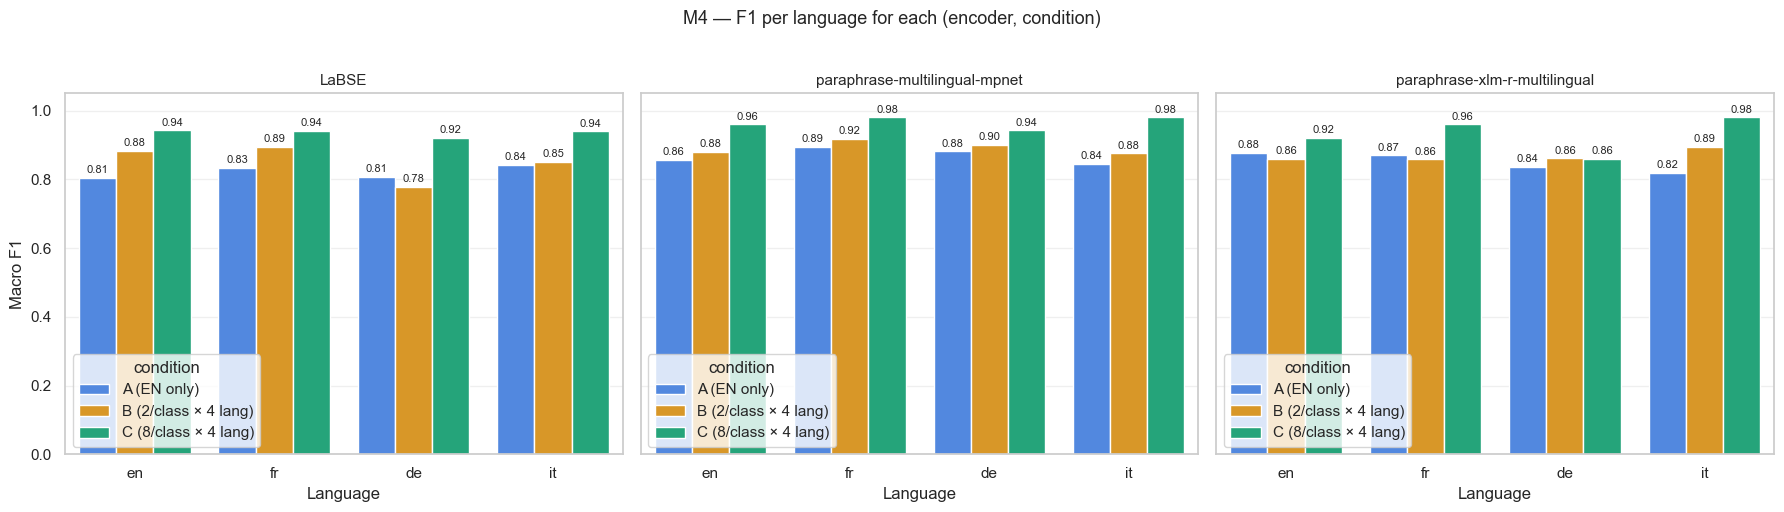

In [9]:
# Visualization: F1 per language for each (encoder, condition) cell
# Long format DataFrame for easy plotting with seaborn

# Reshape results: one row per (encoder, condition, language)
plot_rows = []
for _, row in results_df.iterrows():
    for lang in LANGUAGES:
        plot_rows.append({
            "encoder": row["encoder"],
            "condition": row["condition"],
            "language": lang,
            "f1": row[f"f1_{lang}"],
        })
plot_df = pd.DataFrame(plot_rows)

# Plot: one subplot per encoder, grouped bars by condition × language
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, encoder_name in zip(axes, ENCODERS.keys()):
    encoder_data = plot_df[plot_df["encoder"] == encoder_name]
    
    sns.barplot(
        data=encoder_data,
        x="language", y="f1", hue="condition",
        ax=ax,
        order=LANGUAGES,
        palette=["#3b82f6", "#f59e0b", "#10b981"],
    )
    ax.set_title(encoder_name, fontsize=11)
    ax.set_xlabel("Language")
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.3)
    
    # Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)

axes[0].set_ylabel("Macro F1")
axes[1].set_ylabel("")
axes[2].set_ylabel("")

plt.suptitle("M4 — F1 per language for each (encoder, condition)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()